In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# This cell does not render in the docs because it has a `nbsphinx: hidden` tag.
import warnings

warnings.filterwarnings("ignore")

# Gene Expression Embeddings (Bone Marrow)

This notebook demonstrates how to use Glass Box UMAP on bone marrow single-cell
RNA-seq (scRNA-seq) data. We train a parametric UMAP on PCA-reduced gene expression
profiles, then use exact Jacobian-based attributions to identify which genes most
strongly drive each cell type's position in the embedding.

## Configuration

In [3]:
DEVICE = "mps"       # change to "cuda" or "mps" if available
N_PCS = 200          # number of PCA components used as UMAP input
EPOCHS = 4
REP_STRENGTH = 1.0
N_NEIGHBORS = 64
MIN_DIST = 0.8
BATCH_SIZE = 128 * 4 * 8
NUM_BATCHES = 900
BATCH_KEY = "Samplename"
GROUPBY_KEY = "cell_type"

## Load and Prepare Data

We use the `prepare_data` utility from `utils_gene_exp` to download the BMMC
bone marrow dataset, normalize, filter highly variable genes, and run PCA.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

import sys
sys.path.insert(0, "../../src")      # so glass_box_umap package can be found
sys.path.insert(0, "../../scripts")  # so utils_gene_exp can be imported
from utils_gene_exp import prepare_data, make_tab40_cmap, plot_embedding, plot_top_gene_map, print_top_genes_per_cluster

adata = prepare_data(groupby_key=GROUPBY_KEY, n_pcs=N_PCS, batch_key=BATCH_KEY)

labels = adata.obs[GROUPBY_KEY].astype("category").cat.codes
label_names = adata.obs[GROUPBY_KEY].cat.categories

print(f"Cells: {adata.n_obs}, Genes (HVG): {adata.n_vars}")
print(f"PCA shape: {adata.obsm['X_pca'].shape}")
print(f"Cell types: {list(label_names)}")

--- Starting Preprocessing ---
Cells: 87549, Genes (HVG): 13980
PCA shape: (87549, 200)
Cell types: ['B1 B IGKC+', 'B1 B IGKC-', 'CD4+ T activated', 'CD4+ T activated integrinB7+', 'CD4+ T naive', 'CD8+ T CD49f+', 'CD8+ T CD57+ CD45RA+', 'CD8+ T CD57+ CD45RO+', 'CD8+ T CD69+ CD45RA+', 'CD8+ T CD69+ CD45RO+', 'CD8+ T TIGIT+ CD45RA+', 'CD8+ T TIGIT+ CD45RO+', 'CD8+ T naive', 'CD14+ Mono', 'CD16+ Mono', 'Erythroblast', 'G/M prog', 'HSC', 'Lymph prog', 'MAIT', 'MK/E prog', 'NK', 'NK CD158e1+', 'Naive CD20+ B IGKC+', 'Naive CD20+ B IGKC-', 'Normoblast', 'Proerythroblast', 'Reticulocyte', 'Transitional B', 'cDC2', 'gdT CD158b+', 'pDC']


## Fit Glass Box UMAP

In [5]:
import time
from glass_box_umap import GlassBoxUMAP

t0 = time.time()

reducer = GlassBoxUMAP(
    epochs=EPOCHS,
    lr=1e-4,
    batch_size=BATCH_SIZE,
    num_batches=NUM_BATCHES,
    repulsion_strength=REP_STRENGTH,
    min_dist=MIN_DIST,
    n_neighbors=N_NEIGHBORS,
    encoder_name="default",
    checkpoint_dir=Path("tmp_gene_exp"),
    random_state=11,
    num_workers=10,
)

reducer.fit(adata.obsm["X_pca"])
output = reducer.transform(adata.obsm["X_pca"])

print(f"Training time: {(time.time() - t0) / 60:.1f} min")

Seed set to 11
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Fri Apr  3 10:17:29 2026 Building RP forest with 20 trees
Fri Apr  3 10:17:32 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	Stopping threshold met -- exiting after 4 iterations
n_epochs:  40
Graph len:  7705368 7705368


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ DefaultEncoder │  223 K │ train │     0 │
└───┴─────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 223 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 223 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 24                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=4` reached.


Training time: 3.3 min


## Plot Embedding

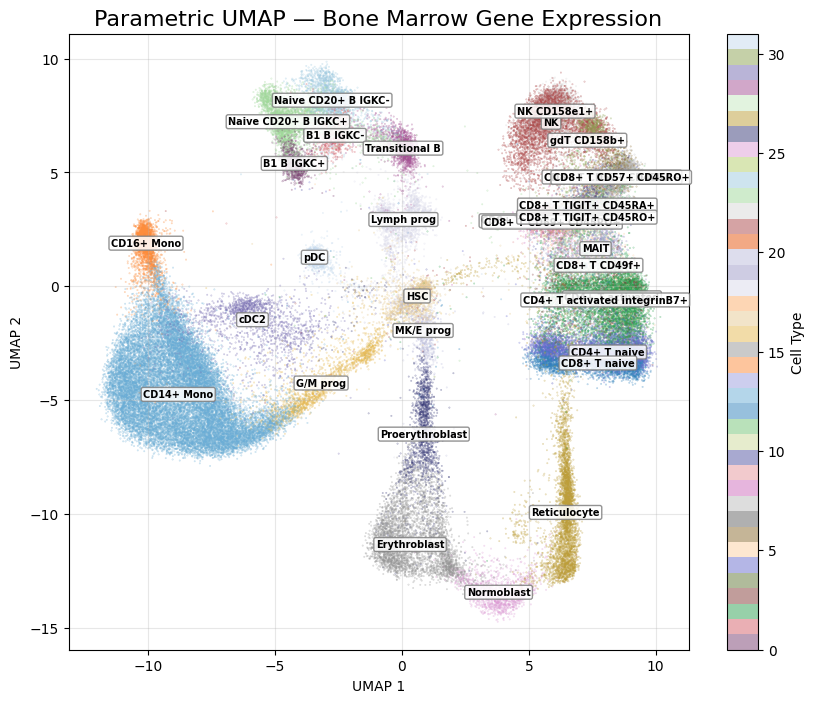

In [ ]:
tab40 = make_tab40_cmap()
plot_embedding(
    output, labels, "tab40",
    f"nb_vis_gene_exp_nn_{N_NEIGHBORS}_md_{MIN_DIST}.png",
    title="Parametric UMAP — Bone Marrow Gene Expression",
    label_names=label_names,
    show=True
)

# plot_embedding(
#     output,
#     labels,
#     "tab40",
#     title="Parametric UMAP — Bone Marrow Gene Expression",
#     filename='vis_gene_exp.png'
# )

## Compute Jacobians

The Jacobian $J_{noi}$ gives the partial derivative of embedding dimension $o$
with respect to PCA component $i$ for cell $n$. Glass Box UMAP computes this
exactly by converting PReLU activations to their piecewise-linear equivalents.

In [9]:
print("Computing Jacobians...")
encoder = reducer._fitted_model.encoder
X_tensor = torch.tensor(adata.obsm["X_pca"], device=reducer._device)

encoder.eval()
with torch.no_grad():
    Z_np = encoder(X_tensor).cpu().numpy()

encoder_for_jac = reducer.prelu_to_leaky(encoder)
J = reducer.compute_jacobian(encoder_for_jac, X_tensor)
J_np = J.cpu().numpy()
X_np = X_tensor.cpu().numpy()

print(f"Jacobian shape: {J_np.shape}  (n_cells, n_embedding_dims, n_pcs)")

Computing Jacobians...
Jacobian shape: (87549, 2, 200)  (n_cells, n_embedding_dims, n_pcs)


### Verify Jacobian Exactness

In [10]:
reducer.verify_jacobian(Z_np, J_np, X_np)


── Jacobian Exactness Verification ──
  f(x)       range : [-14.7222, 10.1789]
  J(x)@x     range : [-14.7222, 10.1789]
  Max |f(x) - J(x)@x|  : 1.53e-05
  Mean |f(x) - J(x)@x| : 1.43e-06
  Relative max error    : 1.04e-06
  Verification PASSED ✓


np.float32(1.0364481e-06)

## Gene-Space Contributions

The Jacobians are in PCA space. We project them back to the original gene space
using `compute_gene_contributions`, which applies the PCA loading matrix to give
per-gene, per-cell contributions to each embedding dimension.

In [11]:
from glass_box_umap.attribution import compute_gene_contributions, verify_gene_reconstruction

contributions_gene, importance_gene, gene_names_hvg = compute_gene_contributions(
    J_np, adata
)
verify_gene_reconstruction(contributions_gene, Z_np)

print(f"Gene contributions shape: {contributions_gene.shape}  (n_cells, n_embedding_dims, n_genes)")
print(f"Gene importance shape:    {importance_gene.shape}  (n_cells, n_genes)")


── Gene-Space Reconstruction ──
  Max error  : 6.74e-05
  Mean error : 3.53e-06
  Rel error  : 4.58e-06
  Verification PASSED ✓
Gene contributions shape: (87549, 2, 2000)  (n_cells, n_embedding_dims, n_genes)
Gene importance shape:    (87549, 2000)  (n_cells, n_genes)


## Top Genes per Cell Type

For each cell type cluster, we rank genes by their mean importance across cells
in that cluster.

In [12]:
print_top_genes_per_cluster(importance_gene, gene_names_hvg, labels.values, label_names)


── Top 8 Genes Per Cluster ──
  B1 B IGKC+: ['IGKC', 'HLA-DRA', 'MS4A1', 'CD79A', 'CD74', 'HLA-DRB1', 'CD37', 'CD79B']
  B1 B IGKC-: ['IGLC2', 'HLA-DRA', 'MS4A1', 'IGLC3', 'CD79A', 'HLA-DRB1', 'IGHM', 'IGKC']
  CD4+ T activated: ['IL7R', 'HLA-DRA', 'LTB', 'IL32', 'CD3D', 'CRIP1', 'CD3G', 'S100A11']
  CD4+ T activated integrinB7+: ['IL7R', 'HLA-DRA', 'LTB', 'IL32', 'CD3D', 'CD3G', 'CRIP1', 'HBB']
  CD4+ T naive: ['HLA-DRA', 'LTB', 'CD3D', 'IL7R', 'IL32', 'S100A4', 'CD3G', 'HBB']
  CD8+ T CD49f+: ['IL7R', 'HLA-DRA', 'CCL5', 'IL32', 'CD3D', 'GNLY', 'LTB', 'NKG7']
  CD8+ T CD57+ CD45RA+: ['GNLY', 'NKG7', 'CCL5', 'IL32', 'CD3D', 'GZMH', 'GZMA', 'HLA-DRA']
  CD8+ T CD57+ CD45RO+: ['GNLY', 'NKG7', 'CCL5', 'IL32', 'CD3D', 'GZMH', 'GZMA', 'HLA-DRA']
  CD8+ T CD69+ CD45RA+: ['CCL5', 'NKG7', 'IL32', 'HLA-DRA', 'GZMA', 'CD3D', 'CCL4', 'CD3G']
  CD8+ T CD69+ CD45RO+: ['CCL5', 'NKG7', 'IL32', 'GZMA', 'HLA-DRA', 'CD3D', 'CCL4', 'CD3G']
  CD8+ T TIGIT+ CD45RA+: ['NKG7', 'CCL5', 'GNLY', 'HLA-DRA', 'CD

## Top-Gene Colored UMAP

For each cell, we identify its single most important gene and color the embedding
by that gene. This shows which genes dominate different regions of the embedding.

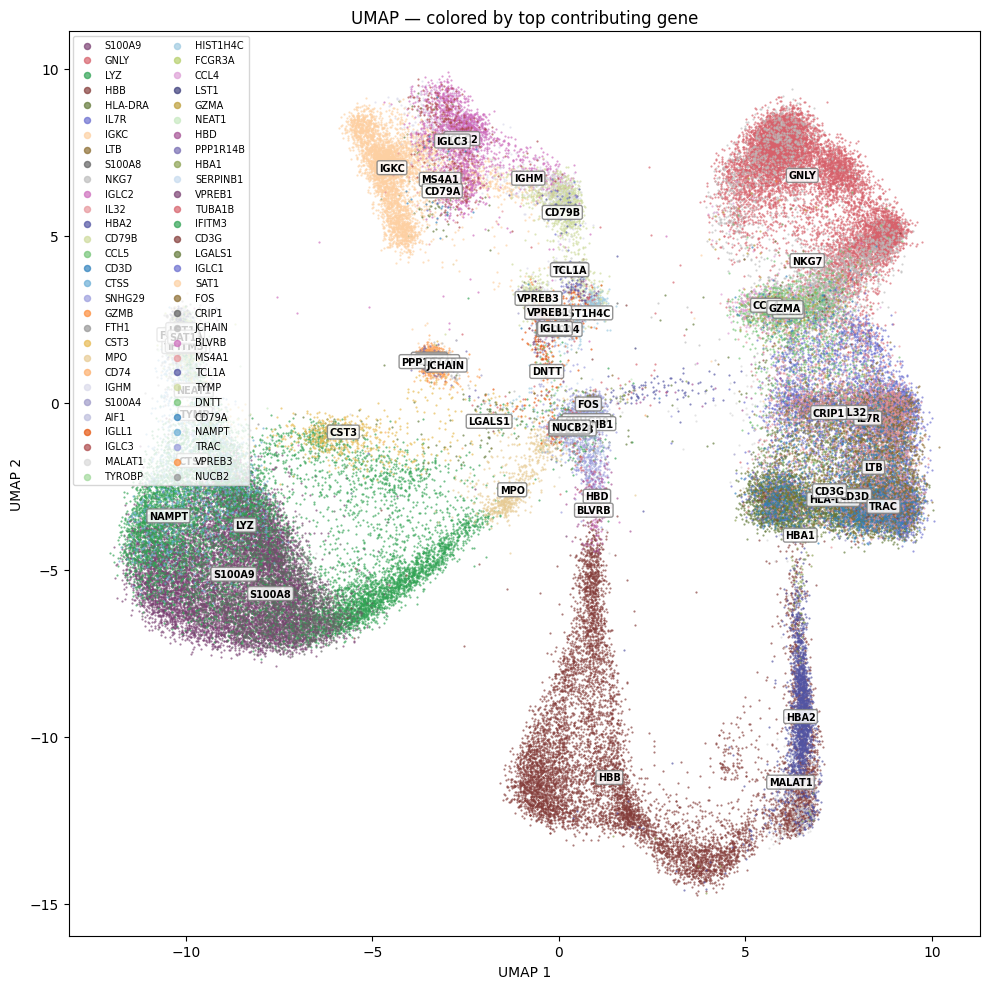

In [ ]:
top_gene_idx = np.argmax(importance_gene, axis=1)
top_gene_names = gene_names_hvg[top_gene_idx]

plot_top_gene_map(
    Z_np,
    top_gene_names,
    gene_names_hvg,
    # title="Top Gene Colored UMAP — Bone Marrow",
    filename="nb_features_nn_{N_NEIGHBORS}_md_{MIN_DIST}.png",
    show=True
)